In [ ]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from typing import TypedDict
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langgraph.checkpoint.memory import InMemorySaver

load_dotenv()

True

In [2]:
# llm 
model = ChatOpenAI()

# parsers
parser = StrOutputParser()

In [3]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

In [4]:
def gen_joke(state: JokeState):

    prompt = PromptTemplate(
        template="""
        Generate a small joke on the following topic \n
        {topic}
        """,
        input_variables=["topic"],
    )

    chain = prompt | model | parser

    res = chain.invoke({"topic": state["topic"]})

    return {"joke": res}

In [5]:
def exp_joke(state: JokeState):

    prompt = PromptTemplate(
        template="""
        Explain the following joke in not more that 200 chars \n
        {joke}
        """,
        input_variables=["joke"],
    )

    chain = prompt | model | parser

    res = chain.invoke({"joke": state["joke"]})

    return {"explanation": res}

In [10]:
# define graph
graph = StateGraph(JokeState)

# add nodes
graph.add_node('gen_joke', gen_joke)
graph.add_node('exp_joke', exp_joke)

# add edges
graph.add_edge(START, 'gen_joke')
graph.add_edge('gen_joke', 'exp_joke')
graph.add_edge('exp_joke', END)

checkpointer = InMemorySaver()

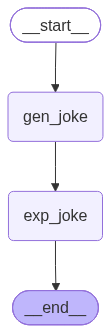

In [11]:
workflow = graph.compile(checkpointer=checkpointer)
workflow

In [16]:
config1 = {"configurable": {"thread_id": "1"}}
initial_state = {"topic": "books"}
final_state = workflow.invoke(initial_state, config=config1)

In [17]:
print(final_state)

{'topic': 'books', 'joke': 'Why did the book go to therapy? \nBecause it had too many unresolved plot twists!', 'explanation': 'The book went to therapy because it had too many unresolved plot twists, indicating that the book was struggling with its own storytelling issues.'}


In [18]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'books', 'joke': 'Why did the book go to therapy? \nBecause it had too many unresolved plot twists!', 'explanation': 'The book went to therapy because it had too many unresolved plot twists, indicating that the book was struggling with its own storytelling issues.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1916f0-4e94-62a7-8006-d4f22add9998'}}, metadata={'source': 'loop', 'step': 6, 'parents': {}}, created_at='2026-08-06T08:15:43.498922+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1916f0-3f53-6ff8-8005-3c1f801d3c4c'}}, tasks=(), interrupts=())

In [22]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'books', 'joke': 'Why did the book go to therapy? \nBecause it had too many unresolved plot twists!', 'explanation': 'The book went to therapy because it had too many unresolved plot twists, indicating that the book was struggling with its own storytelling issues.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1916f0-4e94-62a7-8006-d4f22add9998'}}, metadata={'source': 'loop', 'step': 6, 'parents': {}}, created_at='2026-08-06T08:15:43.498922+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1916f0-3f53-6ff8-8005-3c1f801d3c4c'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'books', 'joke': 'Why did the book go to therapy? \nBecause it had too many unresolved plot twists!', 'explanation': 'The joke is playing on the idea of "reception" as both the signal quality on a phone and the way one is received by others. The phone went to school to improve 

### Time Travel -> used for debugging

In [24]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f1916eb-a499-6546-8001-ec37f3eb64d9"}})

StateSnapshot(values={'topic': 'smart phone', 'joke': 'Why did the smart phone go to school?\n\nBecause it wanted to improve its reception!'}, next=('exp_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f1916eb-a499-6546-8001-ec37f3eb64d9'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-08-06T08:13:38.301063+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1916eb-83db-6b06-8000-555c169e80df'}}, tasks=(PregelTask(id='9e2f6e07-e033-eff5-8d86-4536e7185b42', name='exp_joke', path=('__pregel_pull', 'exp_joke'), error=None, interrupts=(), state=None, result={'explanation': 'The joke is playing on the idea of "reception" as both the signal quality on a phone and the way one is received by others. The phone went to school to improve both.'}),), interrupts=())

In [25]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f1916eb-a499-6546-8001-ec37f3eb64d9"}})

{'topic': 'smart phone',
 'joke': 'Why did the smart phone go to school?\n\nBecause it wanted to improve its reception!',
 'explanation': 'The smart phone went to school to improve its reception, as in signal strength, but also implying to improve its education and knowledge.'}

In [26]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'smart phone', 'joke': 'Why did the smart phone go to school?\n\nBecause it wanted to improve its reception!', 'explanation': 'The smart phone went to school to improve its reception, as in signal strength, but also implying to improve its education and knowledge.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19171d-4008-6cca-8003-adb898c85df6'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-08-06T08:35:49.933383+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19171d-24fe-6001-8002-99083d37d61c'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'smart phone', 'joke': 'Why did the smart phone go to school?\n\nBecause it wanted to improve its reception!'}, next=('exp_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19171d-24fe-6001-8002-99083d37d61c'}}, metadata={'source': 'fo

### Updating state

In [37]:
workflow.update_state(
    {
        "configurable": {
            "thread_id": "1",
            "checkpoint_id": "1f1916eb-83db-6b06-8000-555c169e80df",
            "checkpoint_ns": "",
        }
    },
    {"topic": "pizza"},
)

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f19172a-a825-6514-8001-23692227300d'}}

In [38]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza'}, next=('gen_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19172a-a825-6514-8001-23692227300d'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-08-06T08:41:49.816347+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1916eb-83db-6b06-8000-555c169e80df'}}, tasks=(PregelTask(id='7ccbf80e-425e-a0aa-26a3-d9b4d9cb2a72', name='gen_joke', path=('__pregel_pull', 'gen_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'smart phone', 'joke': 'Why did the smart phone go to school?\n\nBecause it wanted to improve its reception!', 'explanation': 'The smart phone went to school to improve its reception, as in signal strength, but also implying to improve its education and knowledge.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f191

In [39]:
workflow.invoke(
    None,
    {
        "configurable": {
            "thread_id": "1",
            "checkpoint_id": "1f19172a-a825-6514-8001-23692227300d",
        }
    },
)

{'topic': 'pizza',
 'joke': 'Why did the pizza go to the party?\n\nBecause it was a real "slice" of life!',
 'explanation': 'The pizza went to the party because it was a literal "slice" of life, playing on the word slice as a piece of pizza and as a representation of life experiences.'}

In [40]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the party?\n\nBecause it was a real "slice" of life!', 'explanation': 'The pizza went to the party because it was a literal "slice" of life, playing on the word slice as a piece of pizza and as a representation of life experiences.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f191733-a3c2-6e94-8003-bf4b631ec0c0'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-08-06T08:45:50.948520+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f191733-92c6-6599-8002-92ed42849575'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the party?\n\nBecause it was a real "slice" of life!'}, next=('exp_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f191733-92c6-6599-8002-92ed42849575'}}, metadata={'source': 'loop', 